In [2]:
words=open('names.txt','r').read().splitlines()


In [3]:
import numpy as np

In [4]:
words

['isabella',
 'newton',
 'plank',
 'prince',
 'pravas',
 'saksham',
 'roman',
 'rabin',
 'ritesh',
 'pratyush',
 'ritika',
 'nischal',
 'animesh',
 'sabin',
 'sanjiv',
 'sunil']

In [5]:
for w in words[:5]:
    for c1,c2 in zip(w,w[1:]):
        print(c1,c2)
# everything is good but we have no idea which letter is teh starting word which is vey important for me :)))

i s
s a
a b
b e
e l
l l
l a
n e
e w
w t
t o
o n
p l
l a
a n
n k
p r
r i
i n
n c
c e
p r
r a
a v
v a
a s


In [6]:
b={}
for w in words:
    ws0=['.']+list(w)+['.']
# for every word you get do one thing , add s and e at the end so that i know it
    
    for c1,c2 in zip(ws0,ws0[1:]):
        bigram=(c1,c2)
        b[bigram]=b.get(bigram,0)+1
        # print(c1,c2)

In [7]:
sorted(b.items(),key= lambda x:x[1],reverse=True)

[(('s', 'a'), 4),
 (('n', '.'), 4),
 (('.', 'p'), 4),
 (('a', 'n'), 4),
 (('.', 's'), 4),
 (('s', 'h'), 4),
 (('.', 'r'), 4),
 (('a', 'b'), 3),
 (('p', 'r'), 3),
 (('r', 'i'), 3),
 (('i', 'n'), 3),
 (('r', 'a'), 3),
 (('h', '.'), 3),
 (('n', 'i'), 3),
 (('i', 's'), 2),
 (('l', 'a'), 2),
 (('a', '.'), 2),
 (('.', 'n'), 2),
 (('h', 'a'), 2),
 (('b', 'i'), 2),
 (('i', 't'), 2),
 (('e', 's'), 2),
 (('l', '.'), 2),
 (('.', 'i'), 1),
 (('b', 'e'), 1),
 (('e', 'l'), 1),
 (('l', 'l'), 1),
 (('n', 'e'), 1),
 (('e', 'w'), 1),
 (('w', 't'), 1),
 (('t', 'o'), 1),
 (('o', 'n'), 1),
 (('p', 'l'), 1),
 (('n', 'k'), 1),
 (('k', '.'), 1),
 (('n', 'c'), 1),
 (('c', 'e'), 1),
 (('e', '.'), 1),
 (('a', 'v'), 1),
 (('v', 'a'), 1),
 (('a', 's'), 1),
 (('s', '.'), 1),
 (('a', 'k'), 1),
 (('k', 's'), 1),
 (('a', 'm'), 1),
 (('m', '.'), 1),
 (('r', 'o'), 1),
 (('o', 'm'), 1),
 (('m', 'a'), 1),
 (('t', 'e'), 1),
 (('a', 't'), 1),
 (('t', 'y'), 1),
 (('y', 'u'), 1),
 (('u', 's'), 1),
 (('t', 'i'), 1),
 (('i', 'k

In [8]:
# lets make a 2d array for this
import torch

In [9]:
N=torch.zeros((27,27),dtype=torch.int32)

In [10]:
chars=sorted(list(set(''.join(words))))
chtoi={c:i+1 for i,c in enumerate(chars)}

chtoi ['.'] = 0

itoc = {v:k for k,v in chtoi.items()}


In [11]:
chtoi

{'a': 1,
 'b': 2,
 'c': 3,
 'e': 4,
 'h': 5,
 'i': 6,
 'j': 7,
 'k': 8,
 'l': 9,
 'm': 10,
 'n': 11,
 'o': 12,
 'p': 13,
 'r': 14,
 's': 15,
 't': 16,
 'u': 17,
 'v': 18,
 'w': 19,
 'y': 20,
 '.': 0}

In [12]:
b={}
for w in words:
    ws0=['.']+list(w)+['.']
# for every word you get do one thing , add s and e at the end so that i know it
    
    for c1,c2 in zip(ws0,ws0[1:]):
        ix1 = chtoi[c1]
        ix2 = chtoi[c2]

        N[ix1,ix2] += 1
        # print(c1,c2)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

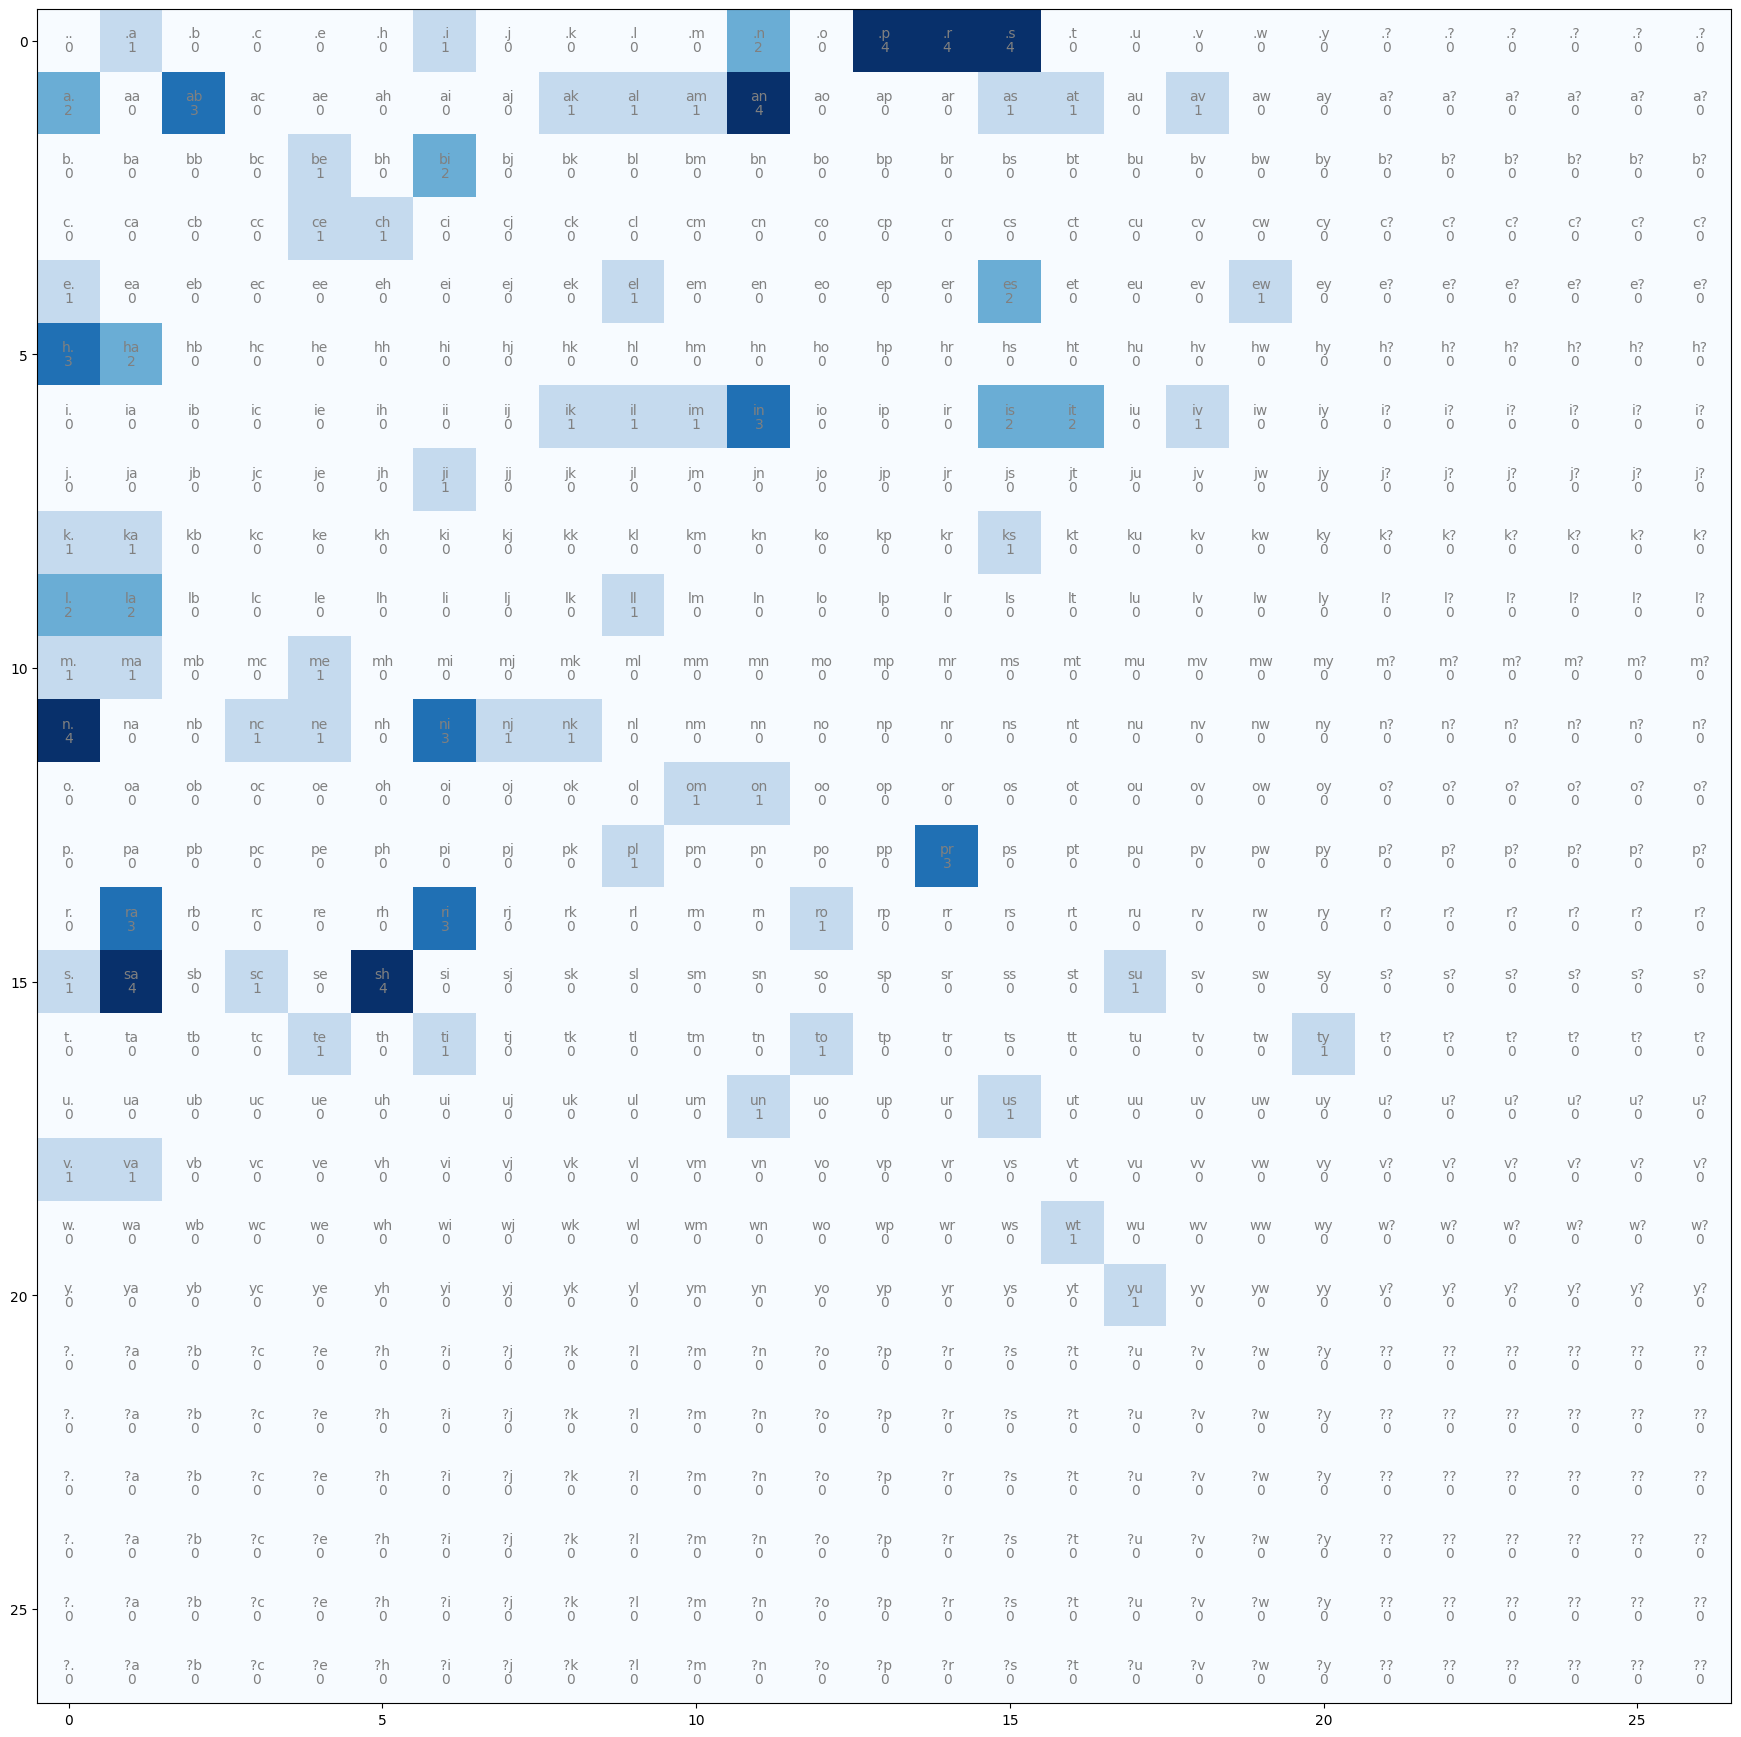

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize = (22,22))
plt.imshow(N, cmap = 'Blues')
for i in range (27):
    for j in range(27):
        chrstr = itoc.get(i, '?') + itoc.get(j, '?')
        plt.text(j,i, chrstr, va="bottom",color = 'gray',ha = 'center')
        plt.text(j,i, N[i,j].item(), ha="center",va = "top",color = 'gray')
plt.axes('off')

In [17]:
p = N[0].float()
p = N[0] /N[0].sum()
p

tensor([0.0000, 0.0625, 0.0000, 0.0000, 0.0000, 0.0000, 0.0625, 0.0000, 0.0000,
        0.0000, 0.0000, 0.1250, 0.0000, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

In [57]:
idx = 0
generator = torch.Generator().manual_seed(2121)
for _ in range (10):
    while (True):
        row_sum = N[idx].sum()
        if row_sum == 0:
            break
        p = N[idx].float() / row_sum
        next_idx = torch.multinomial(input = p,num_samples = 1 ,generator=generator).item()
        print(itoc[next_idx],end = '')
        if itoc[next_idx] == '.':
            break
        idx = next_idx
    print("\n")

        # its almost always r , p or s


sasusun.

.

.

.

esan.

ks.

a.

nk.

shabityusanch.

a.

